# Jupyter-Notebook zur Bestimmung der Wärmeleitfähigkeiten im Versuch Wärmetransport

Dieses Notebook soll als Hilfestellung dienen bei Durchführung und Auswertung des Versuchs.
Alle Stellen, an denen Sie aktiv werden müssen, sind mit TODO: gekennzeichnet. Abschnitt 5.2 können Sie alternativ auch auf Papier bearbeiten. 


In [13]:
# Laden benötigter Bibliotheken
import pandas as pd
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 5.2 Bestimmung der Wärmeleitfähigkeit aus der stationären Wärmeleitung

Für die stationäre Wärmeleitung in diesem einfachen Aufbau gilt:

$P=\lambda \cdot A \cdot \frac{\Delta T}{l}$

(Diesen Teil können Sie auch auf Papier rechnen.)

In [14]:
## Werte aus der Messung
A = 10e-3 * 2e-3  # Querschnittsfläche: 10mm x 2mm = 2e-5 m²
l = 0.02           # Länge: 2cm = 0.02 m
U = 16.4           # Spannung in V
I = 50e-3          # Stromstärke: 50mA = 0.05 A
P = U * I          # Leistung in W
print(f"Leistung P = {P:.3f} W")

# --- Aluminium ---
T1_Al = 37.3  # °C (warm)
T2_Al = 34.2  # °C (kalt)
lambda_Al = P * l / (A * abs(T1_Al - T2_Al))
print(f"\nAluminium:")
print(f"  ΔT = {abs(T1_Al - T2_Al):.1f} K")
print(f"  Wärmeleitfähigkeit λ = {lambda_Al:.1f} W/(m·K)")
print(f"  Literaturwert: 220 - 240 W/(m·K)")

# --- Kupfer ---
T1_Cu = 34.0  # °C (warm)
T2_Cu = 32.6  # °C (kalt)
lambda_Cu = P * l / (A * abs(T1_Cu - T2_Cu))
print(f"\nKupfer:")
print(f"  ΔT = {abs(T1_Cu - T2_Cu):.1f} K")
print(f"  Wärmeleitfähigkeit λ = {lambda_Cu:.1f} W/(m·K)")
print(f"  Literaturwert: 330 - 400 W/(m·K)")

Leistung P = 0.820 W

Aluminium:
  ΔT = 3.1 K
  Wärmeleitfähigkeit λ = 264.5 W/(m·K)
  Literaturwert: 220 - 240 W/(m·K)

Kupfer:
  ΔT = 1.4 K
  Wärmeleitfähigkeit λ = 585.7 W/(m·K)
  Literaturwert: 330 - 400 W/(m·K)


In [15]:
# Unsicherheit der stationären Messung abschätzen (Gaußsche Fehlerfortpflanzung)
# λ = P·l / (A·ΔT)
# Unsicherheitsquellen: ΔT (Thermometer), l (Lineal), A (Maße), P (Multimeter)

# Geschätzte Unsicherheiten
delta_T_err = 0.5    # °C (Auflösung Thermometer)
l_err = 0.001        # m (1mm Unsicherheit)
A_err = 0.5e-3 * 0.5e-3  # m² (je 0.5mm Unsicherheit pro Dimension, vereinfacht)
P_err = 0.01 * P     # 1% Unsicherheit im Multimeter

# Für Aluminium
dT_Al = abs(T1_Al - T2_Al)
# Relative Unsicherheiten
rel_P = P_err / P
rel_l = l_err / l
rel_A = A_err / A
rel_dT_Al = np.sqrt(2) * delta_T_err / dT_Al  # zwei Temperaturmessungen

rel_lambda_Al = np.sqrt(rel_P**2 + rel_l**2 + rel_A**2 + rel_dT_Al**2)
lambda_Al_err = lambda_Al * rel_lambda_Al

print(f"Aluminium: λ = {lambda_Al:.0f} ± {lambda_Al_err:.0f} W/(m·K)")
print(f"  Relative Unsicherheit: {rel_lambda_Al*100:.1f}%")
print(f"  Größte Beiträge: ΔT ({rel_dT_Al*100:.1f}%), A ({rel_A*100:.1f}%), l ({rel_l*100:.1f}%)")

# Für Kupfer
dT_Cu = abs(T1_Cu - T2_Cu)
rel_dT_Cu = np.sqrt(2) * delta_T_err / dT_Cu
rel_lambda_Cu = np.sqrt(rel_P**2 + rel_l**2 + rel_A**2 + rel_dT_Cu**2)
lambda_Cu_err = lambda_Cu * rel_lambda_Cu

print(f"\nKupfer: λ = {lambda_Cu:.0f} ± {lambda_Cu_err:.0f} W/(m·K)")
print(f"  Relative Unsicherheit: {rel_lambda_Cu*100:.1f}%")
print(f"  Größte Beiträge: ΔT ({rel_dT_Cu*100:.1f}%), A ({rel_A*100:.1f}%), l ({rel_l*100:.1f}%)")

Aluminium: λ = 265 ± 62 W/(m·K)
  Relative Unsicherheit: 23.4%
  Größte Beiträge: ΔT (22.8%), A (1.2%), l (5.0%)

Kupfer: λ = 586 ± 297 W/(m·K)
  Relative Unsicherheit: 50.8%
  Größte Beiträge: ΔT (50.5%), A (1.2%), l (5.0%)


## 5.3 Bestimmung der Wärmeleitfähigkeit aus der instationären Wärmeleitung

Für die instationäre Wärmeleitung gilt (Anleitung Gleichung 4):

$T(x,t)=(T_1-T_2)\cdot erf(\frac{x}{\sqrt{4ft}})+T_2$ mit $erf(x)=\frac{2}{\sqrt{\pi}}\int_0^x e^{-z^2}dz$, $f=\frac{\lambda}{\rho c}$

### Daten einlesen und plotten

Gehen Sie folgendermaßen vor:
- Lesen Sie die Daten ein. 
- Überlegen Sie sich eine geeignete Umrechnung von Pixel in mm und erstellen Sie eine neue Spalte mit der Position in mm. 
- Plotten Sie die Daten.
- Erstellen Sie ein neues Dataframe, in dem nur der Bereich des kälteren Blocks enthalten ist.

In [16]:
# Daten einlesen
data = pd.read_csv('Gruppe5.csv', sep=';', decimal=',', skiprows=4, header=None) # Dateiname eingetragen
data = data.drop(data.columns[0], axis=1) # string 'Frame 1' aus Rohdaten entfernen
data = data.T # Transponieren von Zeile zu Spalte
data = data.rename(columns={0: 'Messwerte'}) # Benennung der Spalte als "Messwerte"
data.head()

,Messwerte
1,29.362
2,29.362
3,29.352
4,29.352
5,29.347


In [17]:
# TODO: Kalibrationsfaktor bestimmen und kalibrierte Position in mm als Spalte hinzufügen
u = 60.0 / 108.0 # Kalibrationsfaktor: Ein 60mm Block entspricht ca. 108 Pixel

# Spalte Hinzufügen mit Position in mm
data['Position'] = data.index*u
data.head() # erste Zeilen zur Kontrolle anschauen

,Messwerte,Position
1,29.362,0.555556
2,29.362,1.111111
3,29.352,1.666667
4,29.352,2.222222
5,29.347,2.777778


In [18]:
# Daten plotten in interaktivem Graph (falls das nicht klappt, nuten Sie einen "normalen" Graph mit plt.plot(...))
import plotly.express as px

In [19]:
fig=px.scatter(data, x='Position', y='Messwerte', title='interaktives Streudiagramm')
fig.update_xaxes(title_text='Position / mm')
fig.update_yaxes(title_text='T/ °C')
fig.show()

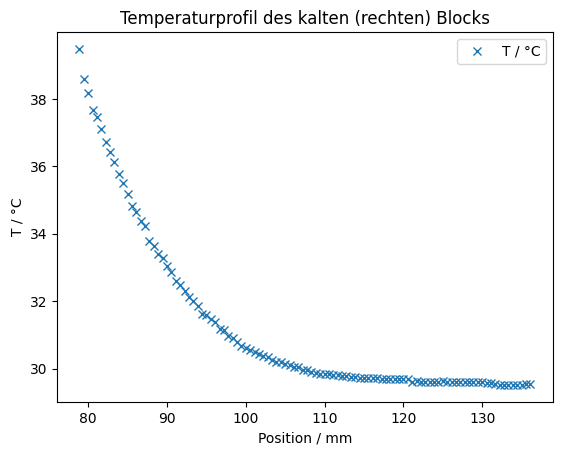

In [20]:
# Neuer DataFrame nur mit Daten des kälteren (rechten) Blocks
# Kontaktstelle bei Pixel-Index 141 (Temperatursprung von 40.9 auf 39.5 C = physische Grenze)
# Kalter Block: 108 Pixel = 60mm -> bis Pixel 249

data_cold = data[(data['Position'] > 141 * u) & (data['Position'] < 246 * u)] # kalter Block ab Kontaktstelle
data_cold = data_cold.dropna() # sonst Fehlermeldung bei Fitfunktion
# plot data
plt.plot(data_cold['Position'], data_cold['Messwerte'], 'x', label='T / °C')
plt.xlabel('Position / mm')
plt.ylabel('T / °C')
plt.title('Temperaturprofil des kalten (rechten) Blocks')
plt.legend()
plt.show()

### Daten fitten und plotten

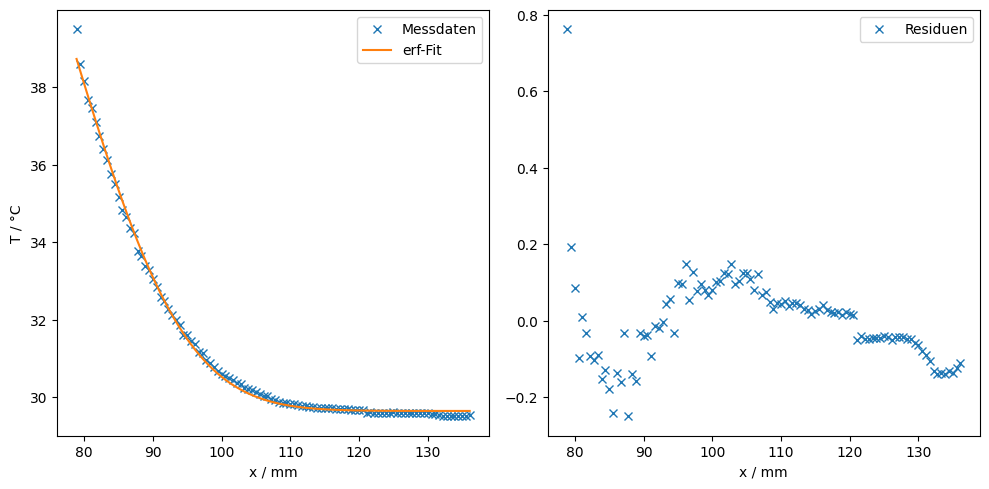

In [21]:
# Definition der Fitfunktion
t = 30 # Messdauer in Sekunden
x_0 = 141 * u # Kontaktstelle in mm (Pixel 141 * Kalibrationsfaktor)
def fitfunction(x, T2, T1, f):
    return (T1-T2)*sc.erf((x-x_0)/(np.sqrt(4*f*t)))+T2

# Startwerte: T2 ~ 39°C (Kontakttemperatur), T1 ~ 29.5°C (Anfangstemperatur kalt), f ~ 3 mm²/s
initial_guess = [39.0, 29.5, 3.0]

# Physikalisch sinnvolle Grenzen
param_bounds=([30,25,0.1],[55,35,50])

# Hier wird der Fit ausgeführt
params, covariance = curve_fit(fitfunction,data_cold.Position, data_cold.Messwerte, p0=initial_guess, bounds=param_bounds)

# plot data, fit and residuals 
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(data_cold['Position'], data_cold['Messwerte'], 'x', label='Messdaten')
axs[0].plot(data_cold['Position'], fitfunction(data_cold['Position'], params[0], params[1], params[2]), label='erf-Fit')
axs[1].plot(data_cold['Position'], data_cold['Messwerte']-fitfunction(data_cold['Position'], params[0], params[1], params[2]), 'x', label='Residuen')

axs[1].set_xlabel('x / mm')
axs[0].set_xlabel('x / mm')
axs[0].set_ylabel('T / °C')
axs[0].legend()
axs[1].legend()
plt.tight_layout()
plt.show()

Sehen Fit und Residuendiagramm sinnvoll aus?

TODO: Fit und Residuendiagramm überprüfen und ggf. Startwerte anpassen


### Bestimmung der Wärmeleitfähigkeit aus dem Fit incl. Unsicherheit

$T(x,t)=(T_1-T_2)\cdot erf(\frac{x}{\sqrt{4ft}})+T_2$ mit $erf(x)=\frac{2}{\sqrt{\pi}}\int_0^x e^{-z^2}dz$

$f=\frac{\lambda}{\rho c}$


In [22]:
# Betrachten der Fit-Ausgaben: Parameter und Kovarianzmatrix bzw. Unsicherheiten (Wurzeln der Diagonalelemente der Kovarianzmatrix)
print('Parameter: ', params)
perr = np.sqrt(np.diag(covariance))
print('Unsicherheiten: ', perr)

Parameter:  [39.04460548 29.65268644  2.78419253]
Unsicherheiten:  [0.05027427 0.0169058  0.044279  ]


In [23]:
# Wärmeleitfähigkeit incl. Unsicherheit bestimmen
# f aus dem Fit ist in mm²/s (da Position in mm und t in s)
# Umrechnung in m²/s: f * 1e-6

# Literaturwerte für Edelstahl:
rho = 7800 # kg/m³ (Dichte Edelstahl)
c = 490 # J/(kg·K) (spezifische Wärmekapazität Edelstahl)

f_fit = params[2] * 1e-6 # Umrechnung von mm²/s in m²/s
f_err = perr[2] * 1e-6
lambda_fit = f_fit * rho * c
lambda_err = f_err * rho * c

print(f"Fitparameter: T2 = {params[0]:.2f} ± {perr[0]:.2f} °C")
print(f"Fitparameter: T1 = {params[1]:.2f} ± {perr[1]:.2f} °C")
print(f"Fitparameter: f = {params[2]:.4f} ± {perr[2]:.4f} mm²/s")
print(f"Temperaturleitfähigkeit f = {f_fit:.2e} ± {f_err:.2e} m²/s")
print(f"Wärmeleitfähigkeit λ = {lambda_fit:.1f} ± {lambda_err:.1f} W/(m·K)")
print(f"\nLiteraturwert Edelstahl: 15-25 W/(m·K)")

Fitparameter: T2 = 39.04 ± 0.05 °C
Fitparameter: T1 = 29.65 ± 0.02 °C
Fitparameter: f = 2.7842 ± 0.0443 mm²/s
Temperaturleitfähigkeit f = 2.78e-06 ± 4.43e-08 m²/s
Wärmeleitfähigkeit λ = 10.6 ± 0.2 W/(m·K)

Literaturwert Edelstahl: 15-25 W/(m·K)


### Vergleich der Unsicherheiten bei der Bestimmung der Wärmeleitfähigkeit aus der stationären und instationären Wärmeleitung


In [24]:
# Vergleich der Ergebnisse mit Literaturwerten
print("=== Vergleich: instationäre Messung ===")
print(f"Gemessene Wärmeleitfähigkeit: λ = {lambda_fit:.1f} ± {lambda_err:.1f} W/(m·K)")
print(f"Literaturwert Edelstahl: 15 - 25 W/(m·K)")

# Relative Unsicherheit
rel_err = lambda_err / lambda_fit * 100
print(f"Relative Unsicherheit: {rel_err:.1f} %")

# Signifikante Stellen: bei relativer Unsicherheit > 10% nur 1-2 signifikante Stellen
if rel_err > 10:
    print(f"\nErgebnis (gerundet): λ ≈ {lambda_fit:.0f} ± {lambda_err:.0f} W/(m·K)")
else:
    print(f"\nErgebnis: λ = {lambda_fit:.1f} ± {lambda_err:.1f} W/(m·K)")

# Bewertung
if 15 <= lambda_fit <= 25:
    print("→ Der Messwert liegt im erwarteten Bereich für Edelstahl.")
elif 15 - lambda_err <= lambda_fit <= 25 + lambda_err:
    print("→ Der Messwert liegt innerhalb der Unsicherheit im Bereich des Literaturwerts.")
else:
    print("→ Der Messwert weicht vom Literaturwert ab. Mögliche Fehlerquellen:")
    print("  - Ungenauigkeit der Kalibrierung (Pixel → mm)")
    print("  - Wärmeverluste an die Umgebung")
    print("  - Unsicherheit in der Messdauer")
    print("  - Kontaktwiderstand zwischen den Blöcken")

=== Vergleich: instationäre Messung ===
Gemessene Wärmeleitfähigkeit: λ = 10.6 ± 0.2 W/(m·K)
Literaturwert Edelstahl: 15 - 25 W/(m·K)
Relative Unsicherheit: 1.6 %

Ergebnis: λ = 10.6 ± 0.2 W/(m·K)
→ Der Messwert weicht vom Literaturwert ab. Mögliche Fehlerquellen:
  - Ungenauigkeit der Kalibrierung (Pixel → mm)
  - Wärmeverluste an die Umgebung
  - Unsicherheit in der Messdauer
  - Kontaktwiderstand zwischen den Blöcken
